In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
import hist
import vector
import pandas as pd

from physics.simulation import msq, mcfm
from physics.hzz import zz2l2v

In [14]:
events = mcfm.from_csv('data/zz2l2v/ggZZ_bkg/events.csv')

In [15]:
events_1 ,events_2, events_3 = events.split(1,8,1)
events_1_analyzed = zz2l2v.analyze(events_1)
print()
events_2_analyzed = zz2l2v.analyze(events_2)
print()
events_3_analyzed = zz2l2v.analyze(events_3)

Inclusive |  1.0000010767531111
MET > 100 GeV |  0.13298901900927168
DPhillMET > 2.5 |  0.13298901900927168
DRll < 1.8 |  0.12014101718608765

Inclusive |  1.000001076753112
MET > 100 GeV |  0.12911718461545615
DPhillMET > 2.5 |  0.12911718461545615
DRll < 1.8 |  0.11642864465925039

Inclusive |  1.0000010767531107
MET > 100 GeV |  0.10624259614151897
DPhillMET > 2.5 |  0.10624259614151897
DRll < 1.8 |  0.09676785620985186


In [16]:
events_analyzed = zz2l2v.analyze(events)

Inclusive |  1.0000010767531111
MET > 100 GeV |  0.12685915918520466
DPhillMET > 2.5 |  0.12685915918520466
DRll < 1.8 |  0.1145247074240957


In [17]:
from physics.constants import mZ
mZsq = mZ**2

g1 = vector.array({'px': events_analyzed.kinematics['p1_px'], 'py': events_analyzed.kinematics['p1_py'], 'pz': events_analyzed.kinematics['p1_pz'], 'E': events_analyzed.kinematics['p1_E']})
g2 = vector.array({'px': events_analyzed.kinematics['p2_px'], 'py': events_analyzed.kinematics['p2_py'], 'pz': events_analyzed.kinematics['p2_pz'], 'E': events_analyzed.kinematics['p2_E']})
l1 = vector.array({'px': events_analyzed.kinematics['p3_px'], 'py': events_analyzed.kinematics['p3_py'], 'pz': events_analyzed.kinematics['p3_pz'], 'E': events_analyzed.kinematics['p3_E']})
l2 = vector.array({'px': events_analyzed.kinematics['p4_px'], 'py': events_analyzed.kinematics['p4_py'], 'pz': events_analyzed.kinematics['p4_pz'], 'E': events_analyzed.kinematics['p4_E']})
v1 = vector.array({'px': events_analyzed.kinematics['p5_px'], 'py': events_analyzed.kinematics['p5_py'], 'pz': events_analyzed.kinematics['p5_pz'], 'E': events_analyzed.kinematics['p5_E']})
v2 = vector.array({'px': events_analyzed.kinematics['p6_px'], 'py': events_analyzed.kinematics['p6_py'], 'pz': events_analyzed.kinematics['p6_pz'], 'E': events_analyzed.kinematics['p6_E']})

pt = np.array([l1.pt, l2.pt]).T
indices = np.argsort(pt, axis=1)[:,::-1]
leptons = np.asarray([l1, l2]).T
leptons_sorted = vector.array(np.take_along_axis(leptons, indices, axis=1), dtype=[("px", np.float32), ("py", np.float32), ("pz", np.float32), ("E", np.float32)])

results = {'l1_pt': leptons_sorted[:,0].pt, 'l1_eta': leptons_sorted[:,0].eta, 'l1_phi': leptons_sorted[:,0].phi, 'l1_energy': leptons_sorted[:,0].energy,
        'l2_pt': leptons_sorted[:,1].pt, 'l2_eta': leptons_sorted[:,1].eta, 'l2_phi': leptons_sorted[:,1].phi, 'l2_energy': leptons_sorted[:,1].energy}

l1 = leptons_sorted[:,0]
l2 = leptons_sorted[:,1]

ll = l1+l2
met = (v1+v2).to_2D()

In [18]:
llvv = l1+l2+v1+v2
zz_mt = np.sqrt( (np.sqrt(mZ**2 + ll.to_2D().pt2) + np.sqrt(mZ**2 + met.pt2))**2 - (ll.to_2D() + met).pt2 )

0         7.149073e-09
1         7.556328e-07
2         6.476623e-08
3         3.602600e-08
4         2.098222e-06
              ...     
239838    1.258217e-09
239839    6.169195e-07
239840    2.723092e-08
239841    6.692985e-10
239842    5.767644e-09
Name: wt, Length: 239843, dtype: float64


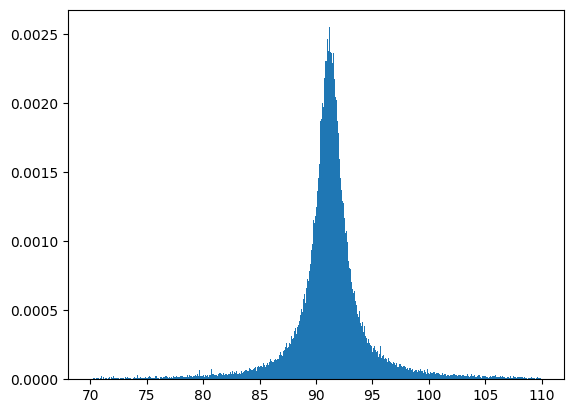

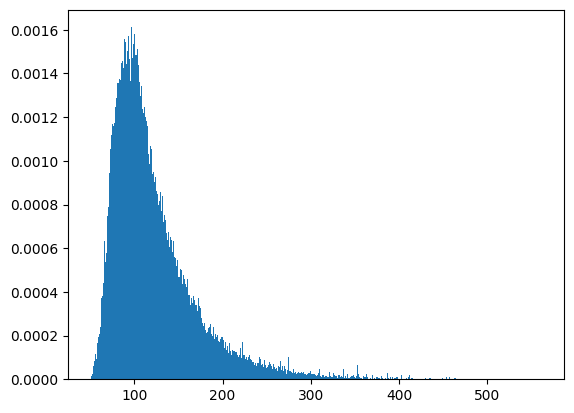

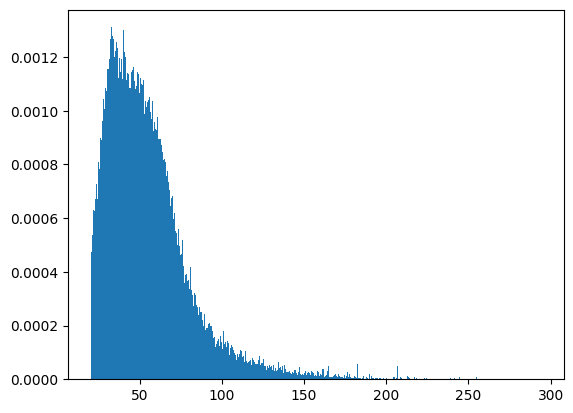

In [ ]:
Z = (l1+l2)
l1_rest = l1.boost( -Z ) # boost to Z reference frame
l2_rest = l2.boost( -Z ) # boost to Z reference frame

print(events_analyzed.weights)

plt.hist(ll.m, weights = events_analyzed.weights, bins=500)
plt.show()

plt.hist(l2.pt, weights = events_analyzed.weights, bins=500)
plt.show()

plt.hist(met.pt, weights = events_analyzed.weights, bins=500)
plt.show()

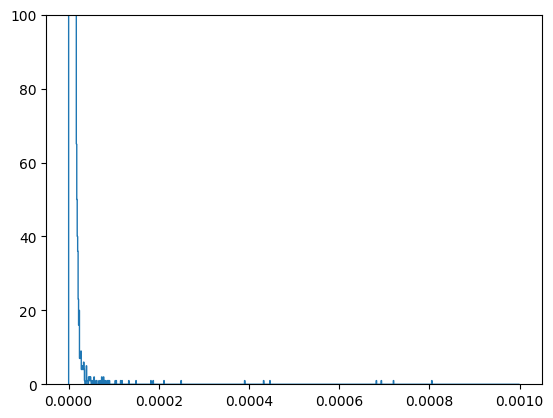

In [20]:
plt.hist(events.weights, bins=1000, range=[0,0.001], histtype='step', label='weights')
plt.ylim(0,100)
plt.show()